In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\Ashish Jape\Desktop\Driver Earnings and Job Satisfaction in the Indian Ride-Hailing Market_ Evidence from Ola, Uber, and Rapido (1).csv")
df.head()

,Vehicle type you use?,Location,Which platform do you Primarily drive for?,"Do you prefer any other platforms, If yes, then which?","Do you prefer any other platforms, If yes, then which?2",Age of driver?,Are you a full-time or part-time driver?,Main reason for preferring platform ?,Driving experience on ride-hailing platforms?,Average Daily Earnings?,...,Please rate the ride demand during the following non‑office hours. [Night (9 PM - 12 AM)],Please rate the ride demand during the following non‑office hours. [Late Night (12 AM - 7 AM)],"Is there any difference for average rides in weekdays and weekends,if yes which days have more rides?","Does riding distance affects your income per ride, if yes, then which type of rides do you prefer?",Biggest challenge you face as a driver,Which app‑related issues do you face most often?,Which improvement would most increase your satisfaction as a driver?,Please rate your satisfaction level for each app [Uber],Please rate your satisfaction level for each app [Ola],Please rate your satisfaction level for each app [Rapido]
0,Car,Airport,Ola,Rapido,NaN,29,Full Time,More rides,1 to 3 years,2500,...,1.0,1.0,"Saturday, Sunday",Shorter,Customer behavior,Delayed ride requests,Higher fares (meter-wise),1.0,3.0,1.0
1,Car,Airport,Ola,Ola,Uber,35,Full Time,More rides,1 to 3 years,1600,...,2.0,4.0,"Monday, Thursday",Shorter,Low earnings,App crashes or slow performance;GPS/location i...,Higher fares (meter-wise),1.0,4.0,1.0
2,Car,Airport,Ola,Uber,NaN,22,Full Time,Lower commission charges,More than 3 years,2200,...,1.0,2.0,"Tuesday, Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
3,Car,Airport,Ola,Rapido,Ola,25,Full Time,More rides,More than 3 years,2000,...,3.0,3.0,"Monday, Tuesday, Friday, Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise);Reduced commission,1.0,4.0,1.0
4,Car,Airport,Uber,Ola,NaN,32,Full Time,More rides,More than 3 years,3000,...,NaN,NaN,"Thursday, Saturday",Not much difference,Low earnings,No issues,More rides,4.0,4.0,1.0


In [3]:
df.isna().sum()

Vehicle type you use?                                                                                     0
Location                                                                                                  0
Which platform do you Primarily drive for?                                                                0
Do you prefer any other platforms, If yes, then which?                                                   14
Do you prefer any other platforms, If yes, then which?2                                                  88
Age of driver?                                                                                            0
Are you a full-time or part-time driver?                                                                  0
Main reason for preferring platform ?                                                                     0
Driving experience on ride-hailing platforms?                                                             0
Average Daily Earnings?     

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 27 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   Vehicle type you use?                                                                                  121 non-null    object 
 1   Location                                                                                               121 non-null    object 
 2   Which platform do you Primarily drive for?                                                             121 non-null    object 
 3   Do you prefer any other platforms, If yes, then which?                                                 107 non-null    object 
 4   Do you prefer any other platforms, If yes, then which?2                                           

# Rename Columns

In [5]:
df.columns

Index(['Vehicle type you use? ', 'Location ',
       'Which platform do you Primarily drive for? ',
       'Do you prefer any other platforms, If yes, then which?',
       'Do you prefer any other platforms, If yes, then which?2',
       'Age of driver?', 'Are you a full-time or part-time driver?',
       'Main reason for preferring platform ?',
       'Driving experience on ride-hailing platforms? ',
       'Average Daily Earnings?',
       'Which platform provides you the highest number of rides? ',
       'How often do you get back-to-back rides on each app?   [Ola]',
       'How often do you get back-to-back rides on each app?   [Uber]',
       'How often do you get back-to-back rides on each app?   [Rapido]',
       'How many rides do you complete daily on average? ',
       'Average working hours per day? ',
       'Please rate the ride demand during the following non‑office hours. [Atfernoon (12 PM - 5 PM)]',
       'Please rate the ride demand during the following non‑office ho

In [6]:
df = df.rename(columns={'Vehicle type you use? ':'vehicle_type',
                       'Location':'location',
                       'Which platform do you Primarily drive for? ':'Primary_platform',
                       'Do you prefer any other platforms, If yes, then which?':'other_platform',
                       'Do you prefer any other platforms, If yes, then which?2':'other_platform_2',
                       'Age of driver?':'age',
                       'Are you a full-time or part-time driver?':'employement_type',
                       'Main reason for preferring platform ?':'main_reason',
                       'Driving experience on ride-hailing platforms? ':'experience_years',
                       'Average Daily Earnings?':'avg_daily_earnings',
                       'Which platform provides you the highest number of rides? ':'platform_highest_rides',
                       'How often do you get back-to-back rides on each app?   [Ola]':'back_to_back_ola',
                       'How often do you get back-to-back rides on each app?   [Uber]':'back_to_back_uber',
                       'How often do you get back-to-back rides on each app?   [Rapido]':'back_to_back_rapido',
                       'How many rides do you complete daily on average? ':'rides_per_day',
                       'Average working hours per day? ':'work_hours',
                       'Please rate the ride demand during the following non‑office hours. [Atfernoon (12 PM - 5 PM)]':'ride_demand_afternoon',
                       'Please rate the ride demand during the following non‑office hours. [Night (9 PM - 12 AM)]':'ride_demand_night',
                       'Please rate the ride demand during the following non‑office hours. [Late Night (12 AM - 7 AM)]':'ride_demand_midnight',
                       'Is there any difference for average rides in weekdays and weekends,if yes which days have more rides?':'more_rides_days',
                       'Does riding distance affects your income per ride, if yes, then which type of rides do you prefer?':'distance_pref',
                       'Biggest challenge you face as a driver  ':'biggest_challenges',
                       'Which app‑related issues do you face most often?':'app_issues',
                       'Which improvement would most increase your satisfaction as a driver? ':'desired_improvement',
                       'Please rate your satisfaction level for each app   [Uber]':'satisfaction_uber',
                       'Please rate your satisfaction level for each app   [Ola]':'satisfaction_ola',
                       'Please rate your satisfaction level for each app   [Rapido]':'satisfaction_rapido'})

In [7]:
age_group = []
for i in df.age:
    if i < 25:
        age_group.append('Below 25')
    elif  25 <= i <= 35:
        age_group.append('25 - 35')
    elif  35 <= i <= 50:
        age_group.append('36 - 50')
    else:
        age_group.append('Above 50')
df['age_group'] = age_group

In [8]:
cols = df.columns.tolist()

cols.remove('age_group')
cols.insert(6, 'age_group')  

df = df[cols]


# Handling Missing Values

In [9]:
df.other_platform.fillna('No',inplace=True)
df.other_platform_2.fillna('No',inplace=True)
df.back_to_back_ola.fillna(0,inplace=True)
df.back_to_back_rapido.fillna(0,inplace=True)
df.back_to_back_uber.fillna(0,inplace=True)
df.ride_demand_afternoon.fillna(0,inplace=True)
df.ride_demand_midnight.fillna(0,inplace=True)
df.ride_demand_night.fillna(0,inplace=True)
df.satisfaction_ola.fillna(0,inplace=True)
df.satisfaction_uber.fillna(0,inplace=True)
df.satisfaction_rapido.fillna(0,inplace=True)

In [10]:
df.head()

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
0,Car,Airport,Ola,Rapido,No,29,25 - 35,Full Time,More rides,1 to 3 years,...,1.0,1.0,"Saturday, Sunday",Shorter,Customer behavior,Delayed ride requests,Higher fares (meter-wise),1.0,3.0,1.0
1,Car,Airport,Ola,Ola,Uber,35,25 - 35,Full Time,More rides,1 to 3 years,...,2.0,4.0,"Monday, Thursday",Shorter,Low earnings,App crashes or slow performance;GPS/location i...,Higher fares (meter-wise),1.0,4.0,1.0
2,Car,Airport,Ola,Uber,No,22,Below 25,Full Time,Lower commission charges,More than 3 years,...,1.0,2.0,"Tuesday, Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
3,Car,Airport,Ola,Rapido,Ola,25,25 - 35,Full Time,More rides,More than 3 years,...,3.0,3.0,"Monday, Tuesday, Friday, Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise);Reduced commission,1.0,4.0,1.0
4,Car,Airport,Uber,Ola,No,32,25 - 35,Full Time,More rides,More than 3 years,...,0.0,0.0,"Thursday, Saturday",Not much difference,Low earnings,No issues,More rides,4.0,4.0,1.0


In [11]:
df.isna().sum()

vehicle_type              0
Location                  0
Primary_platform          0
other_platform            0
other_platform_2          0
age                       0
age_group                 0
employement_type          0
main_reason               0
experience_years          0
avg_daily_earnings        0
platform_highest_rides    0
back_to_back_ola          0
back_to_back_uber         0
back_to_back_rapido       0
rides_per_day             0
work_hours                0
ride_demand_afternoon     0
ride_demand_night         0
ride_demand_midnight      0
more_rides_days           0
distance_pref             0
biggest_challenges        0
app_issues                0
desired_improvement       0
satisfaction_uber         0
satisfaction_ola          0
satisfaction_rapido       0
dtype: int64

# Handling Outliers

<Axes: ylabel='avg_daily_earnings'>

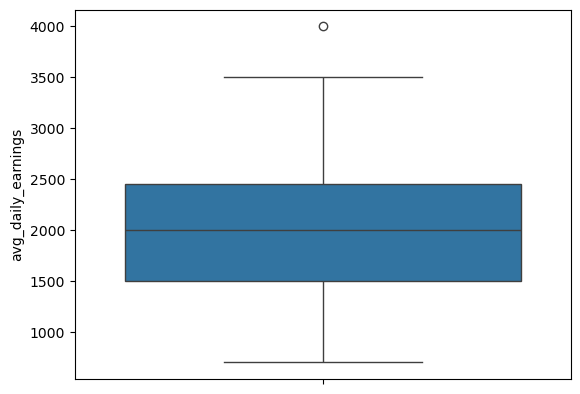

In [12]:
sns.boxplot(df.avg_daily_earnings)

<Axes: ylabel='rides_per_day'>

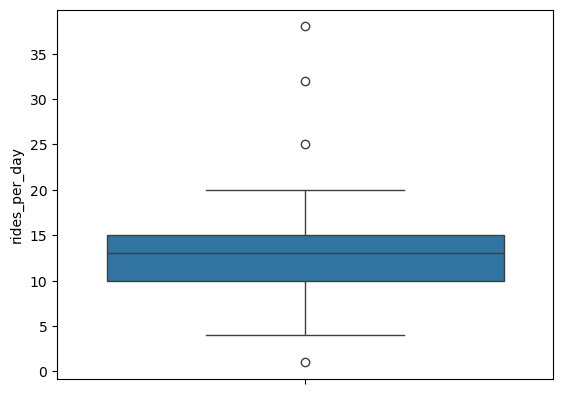

In [13]:
sns.boxplot(df.rides_per_day)

In [14]:
q1 = df['rides_per_day'].quantile(0.25)
q3 = df['rides_per_day'].quantile(0.75)

iqr = q3 - q1
ul = q3 + 1.5 * iqr
ll = q1 - 1.5 * iqr

df['rides_per_day'] = df['rides_per_day'].clip(lower=ll, upper=ul)

<Axes: ylabel='rides_per_day'>

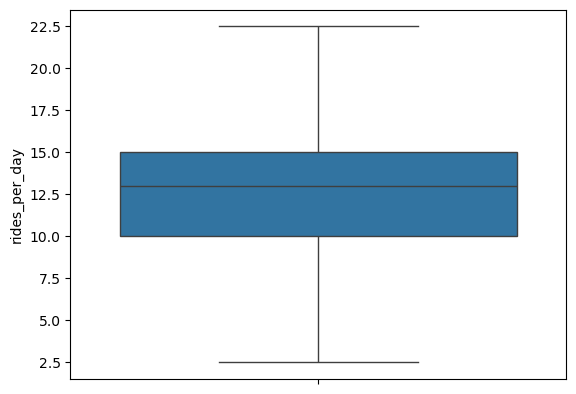

In [15]:
sns.boxplot(df.rides_per_day)

In [16]:
q1 = df['avg_daily_earnings'].quantile(0.25)
q3 = df['avg_daily_earnings'].quantile(0.75)

iqr = q3 - q1
ul = q3 + 1.5 * iqr
ll = q1 - 1.5 * iqr

df['avg_daily_earnings'] = df['avg_daily_earnings'].clip(lower=ll, upper=ul)

<Axes: ylabel='avg_daily_earnings'>

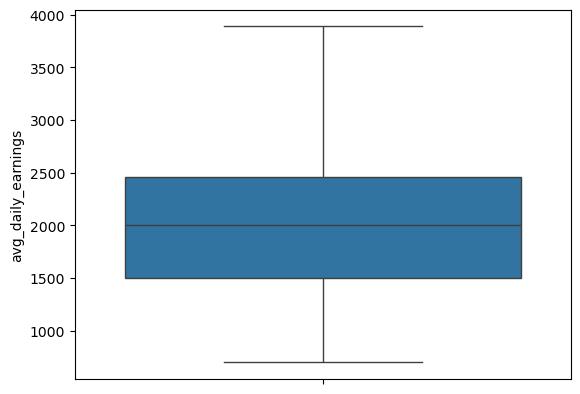

In [17]:
sns.boxplot(df.avg_daily_earnings)

In [18]:
df['desired_improvement'].unique()

array(['Higher fares (meter-wise)',
       'Higher fares (meter-wise);Reduced commission', 'More rides',
       'Reduced commission', 'Reduced commission;More rides',
       'Higher fares (meter-wise);Better customer support',
       'Higher fares (meter-wise);More rides',
       'Higher fares (meter-wise);Better incentives',
       'Better incentives;Better customer support',
       'Better incentives;More rides',
       'More rides;Better customer support',
       'Better incentives;Reduced commission', 'Better incentives'],
      dtype=object)

In [19]:
auto_data = df.loc[df.vehicle_type == 'Auto-rickshaw' , :]
auto_data

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
16,Auto-rickshaw,Malls,Uber,Ola,No,34,25 - 35,Part Time,More rides,1 to 3 years,...,0.0,0.0,Sunday,Shorter,Long waiting times,No issues,Reduced commission,4.0,4.0,1.0
17,Auto-rickshaw,Malls,Uber,Rapido,Ola,29,25 - 35,Full Time,Lower commission charges;More rides,1 to 3 years,...,3.0,0.0,"Monday, Friday, Saturday, Sunday",Not much difference,Long waiting times,No issues,Reduced commission;More rides,4.0,1.0,4.0
20,Auto-rickshaw,Malls,Ola,Rapido,Uber,38,36 - 50,Full Time,More rides,1 to 3 years,...,3.0,0.0,"Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),4.0,1.0,3.0
21,Auto-rickshaw,Malls,Ola,Uber,No,26,25 - 35,Full Time,Lower commission charges,1 to 3 years,...,2.0,0.0,"Saturday, Sunday",Longer,Long waiting times,App crashes or slow performance;GPS/location i...,Higher fares (meter-wise);More rides,1.0,4.0,1.0
23,Auto-rickshaw,Malls,Rapido,Ola,Uber,40,36 - 50,Full Time,Lower commission charges,3 to 5 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Low earnings,No issues,Higher fares (meter-wise),1.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,Auto-rickshaw,Airport,Uber,Ola,No,31,25 - 35,Full Time,Lower commission charges,1 to 3 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Low earnings;Long waiting times,No issues,Higher fares (meter-wise),2.0,2.0,1.0
117,Auto-rickshaw,Random,Uber,Uber,No,41,36 - 50,Full Time,More rides,3 to 5 years,...,3.0,2.0,"Monday, Tuesday, Wednesday, Thursday, Friday",Not much difference,Low earnings;Platform penalties,No issues,Higher fares (meter-wise);More rides,3.0,0.0,0.0
118,Auto-rickshaw,Random,Uber,Uber,No,39,36 - 50,Part Time,More rides,1 to 3 years,...,2.0,1.0,"Friday, Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),4.0,0.0,0.0
119,Auto-rickshaw,Random,Uber,Uber,No,43,36 - 50,Full Time,More rides,3 to 5 years,...,2.0,1.0,"Saturday, Sunday",Longer,Low earnings,GPS/location issues;Delayed ride requests,Higher fares (meter-wise);More rides,4.0,0.0,0.0


In [20]:
cab_data = df.loc[df.vehicle_type == 'Car' , :]
cab_data

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
0,Car,Airport,Ola,Rapido,No,29,25 - 35,Full Time,More rides,1 to 3 years,...,1.0,1.0,"Saturday, Sunday",Shorter,Customer behavior,Delayed ride requests,Higher fares (meter-wise),1.0,3.0,1.0
1,Car,Airport,Ola,Ola,Uber,35,25 - 35,Full Time,More rides,1 to 3 years,...,2.0,4.0,"Monday, Thursday",Shorter,Low earnings,App crashes or slow performance;GPS/location i...,Higher fares (meter-wise),1.0,4.0,1.0
2,Car,Airport,Ola,Uber,No,22,Below 25,Full Time,Lower commission charges,More than 3 years,...,1.0,2.0,"Tuesday, Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
3,Car,Airport,Ola,Rapido,Ola,25,25 - 35,Full Time,More rides,More than 3 years,...,3.0,3.0,"Monday, Tuesday, Friday, Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise);Reduced commission,1.0,4.0,1.0
4,Car,Airport,Uber,Ola,No,32,25 - 35,Full Time,More rides,More than 3 years,...,0.0,0.0,"Thursday, Saturday",Not much difference,Low earnings,No issues,More rides,4.0,4.0,1.0
5,Car,Airport,Ola,Ola,No,35,25 - 35,Full Time,More rides,More than 3 years,...,2.0,2.0,"Thursday, Saturday, Sunday",Longer,Low earnings,GPS/location issues,Higher fares (meter-wise),1.0,4.0,1.0
6,Car,Airport,Uber,No,No,28,25 - 35,Full Time,More rides,More than 3 years,...,3.0,2.0,"Monday, Tuesday, Wednesday, Thursday, Friday, ...",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),4.0,1.0,1.0
7,Car,Airport,Ola,Rapido,No,46,36 - 50,Full Time,More rides,More than 5 years,...,0.0,0.0,"Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise),1.0,4.0,1.0
8,Car,Airport,Ola,No,No,30,25 - 35,Full Time,More rides,More than 5 years,...,2.0,1.0,"Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
9,Car,Airport,Ola,No,No,30,25 - 35,Full Time,More rides,3 to 5 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0


### Is average daily earnings of cab drivers =  population claimed average daily earnings of cab drivers

In [21]:
from statsmodels.stats.weightstats import ztest
test,Pvalue = ztest(cab_data.avg_daily_earnings,value=3500,alternative='two-sided')
print('Test Statistics = ',test)
print('P-value = ',Pvalue) # 0.000009
print('Alpha = ',0.05)

Test Statistics =  -12.799239613267947
P-value =  1.6556442526089164e-37
Alpha =  0.05


##### We reject H0

### Is average daily earnings of Auto-Rickshaw drivers = population claimed average daily earnings of Auto-Rickshaw drivers

In [22]:
from statsmodels.stats.weightstats import ztest
test,Pvalue = ztest(auto_data.avg_daily_earnings,value=1500,alternative='two-sided')
print('Test Statistics = ',test)
print('P-value = ',Pvalue) # 0.000009
print('Alpha = ',0.05)

Test Statistics =  1.2214924599043882
P-value =  0.22189961874407793
Alpha =  0.05


##### We do not Reject H0

In [23]:
# check normality per group (Shapiro) and variance (Levene)
for name, group in df.groupby('Primary_platform'):
    print(name, stats.shapiro(group['avg_daily_earnings'].dropna()))
print(stats.levene(*(g['avg_daily_earnings'].dropna() for _,g in df.groupby('Primary_platform'))))

# If OK -> ANOVA
model = ols('avg_daily_earnings ~ C(Primary_platform)', data=df).fit()
sm.stats.anova_lm(model, typ=2)

Ola ShapiroResult(statistic=0.9716854233977855, pvalue=0.4389391589867887)
Rapido ShapiroResult(statistic=0.9398733279246222, pvalue=0.38078007015431814)
Uber ShapiroResult(statistic=0.9782737681333179, pvalue=0.2809631857204774)
LeveneResult(statistic=0.676021887371746, pvalue=0.5105951408806035)


,sum_sq,df,F,PR(>F)
C(Primary_platform),1.819502e+06,2.0,1.91845,0.151386
Residual,5.595695e+07,118.0,NaN,NaN


In [24]:
ola_data = df.loc[df.Primary_platform == 'Ola' , :]
ola_data

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
0,Car,Airport,Ola,Rapido,No,29,25 - 35,Full Time,More rides,1 to 3 years,...,1.0,1.0,"Saturday, Sunday",Shorter,Customer behavior,Delayed ride requests,Higher fares (meter-wise),1.0,3.0,1.0
1,Car,Airport,Ola,Ola,Uber,35,25 - 35,Full Time,More rides,1 to 3 years,...,2.0,4.0,"Monday, Thursday",Shorter,Low earnings,App crashes or slow performance;GPS/location i...,Higher fares (meter-wise),1.0,4.0,1.0
2,Car,Airport,Ola,Uber,No,22,Below 25,Full Time,Lower commission charges,More than 3 years,...,1.0,2.0,"Tuesday, Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
3,Car,Airport,Ola,Rapido,Ola,25,25 - 35,Full Time,More rides,More than 3 years,...,3.0,3.0,"Monday, Tuesday, Friday, Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise);Reduced commission,1.0,4.0,1.0
5,Car,Airport,Ola,Ola,No,35,25 - 35,Full Time,More rides,More than 3 years,...,2.0,2.0,"Thursday, Saturday, Sunday",Longer,Low earnings,GPS/location issues,Higher fares (meter-wise),1.0,4.0,1.0
7,Car,Airport,Ola,Rapido,No,46,36 - 50,Full Time,More rides,More than 5 years,...,0.0,0.0,"Saturday, Sunday",Shorter,Low earnings,No issues,Higher fares (meter-wise),1.0,4.0,1.0
8,Car,Airport,Ola,No,No,30,25 - 35,Full Time,More rides,More than 5 years,...,2.0,1.0,"Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
9,Car,Airport,Ola,No,No,30,25 - 35,Full Time,More rides,3 to 5 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
10,Car,Airport,Ola,No,No,24,Below 25,Full Time,More rides,1 to 3 years,...,0.0,0.0,"Saturday, Sunday",Shorter,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,1.0
13,Car,Airport,Ola,Uber,No,42,36 - 50,Part Time,More rides,More than 5 years,...,0.0,3.0,Sunday,Longer,Low earnings,No issues,Higher fares (meter-wise),2.0,2.0,2.0


In [25]:
uber_data = df.loc[df.Primary_platform == 'Uber' , :]
uber_data

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
4,Car,Airport,Uber,Ola,No,32,25 - 35,Full Time,More rides,More than 3 years,...,0.0,0.0,"Thursday, Saturday",Not much difference,Low earnings,No issues,More rides,4.0,4.0,1.0
6,Car,Airport,Uber,No,No,28,25 - 35,Full Time,More rides,More than 3 years,...,3.0,2.0,"Monday, Tuesday, Wednesday, Thursday, Friday, ...",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),4.0,1.0,1.0
14,Car,Airport,Uber,No,No,25,25 - 35,Full Time,More rides,More than 5 years,...,0.0,1.0,"Saturday, Sunday",Shorter,Low earnings,GPS/location issues,Higher fares (meter-wise),4.0,3.0,1.0
15,Car,Airport,Uber,No,No,35,25 - 35,Full Time,More rides,More than 5 years,...,0.0,0.0,"Monday, Friday, Saturday, Sunday",Not much difference,Low earnings,No issues,Higher fares (meter-wise),4.0,1.0,1.0
16,Auto-rickshaw,Malls,Uber,Ola,No,34,25 - 35,Part Time,More rides,1 to 3 years,...,0.0,0.0,Sunday,Shorter,Long waiting times,No issues,Reduced commission,4.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,Car,Railway stations,Uber,Rapido,Ola,23,Below 25,Part Time,Lower commission charges;More rides,1 to 3 years,...,2.0,0.0,"Saturday, Sunday",Longer,Low earnings;Long waiting times,No issues,Higher fares (meter-wise),1.0,1.0,1.0
117,Auto-rickshaw,Random,Uber,Uber,No,41,36 - 50,Full Time,More rides,3 to 5 years,...,3.0,2.0,"Monday, Tuesday, Wednesday, Thursday, Friday",Not much difference,Low earnings;Platform penalties,No issues,Higher fares (meter-wise);More rides,3.0,0.0,0.0
118,Auto-rickshaw,Random,Uber,Uber,No,39,36 - 50,Part Time,More rides,1 to 3 years,...,2.0,1.0,"Friday, Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),4.0,0.0,0.0
119,Auto-rickshaw,Random,Uber,Uber,No,43,36 - 50,Full Time,More rides,3 to 5 years,...,2.0,1.0,"Saturday, Sunday",Longer,Low earnings,GPS/location issues;Delayed ride requests,Higher fares (meter-wise);More rides,4.0,0.0,0.0


In [26]:
rapido_data = df.loc[df.Primary_platform == 'Rapido' , :]
rapido_data

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,ride_demand_night,ride_demand_midnight,more_rides_days,distance_pref,biggest_challenges,app_issues,desired_improvement,satisfaction_uber,satisfaction_ola,satisfaction_rapido
11,Car,Airport,Rapido,Uber,Ola,24,Below 25,Full Time,Lower commission charges;More rides,1 to 3 years,...,0.0,2.0,"Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),1.0,4.0,4.0
12,Car,Airport,Rapido,No,No,25,25 - 35,Full Time,Lower commission charges;More rides,1 to 3 years,...,2.0,0.0,"Saturday, Sunday",Longer,Long waiting times,No issues,Higher fares (meter-wise),4.0,2.0,1.0
19,Car,Malls,Rapido,Ola,Uber,39,36 - 50,Part Time,Lower commission charges,1 to 3 years,...,2.0,3.0,"Saturday, Sunday",Shorter,Long waiting times,No issues;GPS/location issues;Poor customer su...,Higher fares (meter-wise);Better customer support,2.0,3.0,3.0
23,Auto-rickshaw,Malls,Rapido,Ola,Uber,40,36 - 50,Full Time,Lower commission charges,3 to 5 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Low earnings,No issues,Higher fares (meter-wise),1.0,1.0,4.0
33,Auto-rickshaw,Malls,Rapido,Uber,No,37,36 - 50,Part Time,Lower commission charges,1 to 3 years,...,0.0,0.0,"Saturday, Sunday",Not much difference,Long waiting times,No issues,Higher fares (meter-wise),3.0,3.0,4.0
34,Auto-rickshaw,Malls,Rapido,Ola,Uber,47,36 - 50,Full Time,Lower commission charges;More rides,1 to 3 years,...,0.0,0.0,Saturday,Longer,Long waiting times,No issues;GPS/location issues,Higher fares (meter-wise),3.0,3.0,3.0
44,Auto-rickshaw,Malls,Rapido,Ola,Uber,22,Below 25,Full Time,Lower commission charges;More rides,1 to 3 years,...,3.0,0.0,Sunday,Longer,Long waiting times,No issues,Higher fares (meter-wise),4.0,4.0,4.0
53,Auto-rickshaw,Railway stations,Rapido,Uber,No,41,36 - 50,Full Time,Lower commission charges,More than 5 years,...,2.0,1.0,"Monday, Sunday",Not much difference,Long waiting times,No issues,Better incentives;Better customer support,3.0,2.0,3.0
60,Auto-rickshaw,Railway stations,Rapido,Rapido,No,27,25 - 35,Part Time,Lower commission charges,1 to 3 years,...,3.0,2.0,"Monday, Saturday, Sunday",Not much difference,Low earnings;Customer behavior,No issues,Better incentives;Reduced commission,2.0,2.0,4.0
69,Auto-rickshaw,Random,Rapido,Uber,No,48,36 - 50,Full Time,More rides,1 to 3 years,...,0.0,0.0,"Monday, Tuesday, Wednesday, Thursday, Friday, ...",Not much difference,Long waiting times,No issues,More rides,1.0,1.0,3.0


### Platform wise average earnings

In [27]:
platform_wise_earning = pd.DataFrame(df.groupby("Primary_platform").agg(Average_Earnings=("avg_daily_earnings","mean")).sort_values(by='Average_Earnings',ascending=False))
round(platform_wise_earning,2)

,Average_Earnings
Primary_platform,
Rapido,2113.33
Ola,2089.37
Uber,1849.41


In [28]:
checkbox_col = 'biggest_challenges'

options = [
    'Low earnings',
    'Long waiting times',
    'Customer behavior',
    'Penalties'
]
for opt in options:
    col_name = 'challenge_' + opt.lower().replace(' ', '_')
    df[col_name] = df[checkbox_col].str.contains(opt, na=False).astype(int)
df[['challenge_low_earnings',
    'challenge_long_waiting_times',
    'challenge_customer_behavior',
    'challenge_penalties']]

,challenge_low_earnings,challenge_long_waiting_times,challenge_customer_behavior,challenge_penalties
0,0,0,1,0
1,1,0,0,0
2,0,1,0,0
3,1,0,0,0
4,1,0,0,0
...,...,...,...,...
116,1,1,0,0
117,1,0,0,0
118,0,1,0,0
119,1,0,0,0


In [29]:
checkbox_col = 'app_issues'

options = [
    'App crashes or slow performance',
    'GPS/location issues',
    'Delayed ride requests',
    'Poor customer support'
]

for opt in options:
    col_name = 'issue_' + opt.lower().replace(' ', '_').replace('/', '_')
    df[col_name] = df[checkbox_col].str.contains(opt, na=False).astype(int)


In [30]:
df

,vehicle_type,Location,Primary_platform,other_platform,other_platform_2,age,age_group,employement_type,main_reason,experience_years,...,satisfaction_ola,satisfaction_rapido,challenge_low_earnings,challenge_long_waiting_times,challenge_customer_behavior,challenge_penalties,issue_app_crashes_or_slow_performance,issue_gps_location_issues,issue_delayed_ride_requests,issue_poor_customer_support
0,Car,Airport,Ola,Rapido,No,29,25 - 35,Full Time,More rides,1 to 3 years,...,3.0,1.0,0,0,1,0,0,0,1,0
1,Car,Airport,Ola,Ola,Uber,35,25 - 35,Full Time,More rides,1 to 3 years,...,4.0,1.0,1,0,0,0,1,1,1,1
2,Car,Airport,Ola,Uber,No,22,Below 25,Full Time,Lower commission charges,More than 3 years,...,4.0,1.0,0,1,0,0,0,0,0,0
3,Car,Airport,Ola,Rapido,Ola,25,25 - 35,Full Time,More rides,More than 3 years,...,4.0,1.0,1,0,0,0,0,0,0,0
4,Car,Airport,Uber,Ola,No,32,25 - 35,Full Time,More rides,More than 3 years,...,4.0,1.0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,Car,Railway stations,Uber,Rapido,Ola,23,Below 25,Part Time,Lower commission charges;More rides,1 to 3 years,...,1.0,1.0,1,1,0,0,0,0,0,0
117,Auto-rickshaw,Random,Uber,Uber,No,41,36 - 50,Full Time,More rides,3 to 5 years,...,0.0,0.0,1,0,0,0,0,0,0,0
118,Auto-rickshaw,Random,Uber,Uber,No,39,36 - 50,Part Time,More rides,1 to 3 years,...,0.0,0.0,0,1,0,0,0,0,0,0
119,Auto-rickshaw,Random,Uber,Uber,No,43,36 - 50,Full Time,More rides,3 to 5 years,...,0.0,0.0,1,0,0,0,0,1,1,0


### Association between platform and biggest challenge

In [31]:
ct = pd.crosstab(df['Primary_platform'], df['challenge_low_earnings'])
ct

challenge_low_earnings,0,1
Primary_platform,,
Ola,21,17
Rapido,11,4
Uber,36,32


In [32]:
chi2, p, dof, expected = stats.chi2_contingency(ct)
expected

array([[21.3553719 , 16.6446281 ],
       [ 8.42975207,  6.57024793],
       [38.21487603, 29.78512397]])

In [33]:
chi2, p, dof, expected = stats.chi2_contingency(ct)
p

0.350688148733233

##### H0 : No significant association between platform and challenge

In [34]:
ct1 = pd.crosstab(df['Primary_platform'], df['challenge_long_waiting_times'])
ct1

challenge_long_waiting_times,0,1
Primary_platform,,
Ola,17,21
Rapido,3,12
Uber,28,40


In [35]:
chi2, p, dof, expected = stats.chi2_contingency(ct1)
expected

array([[15.07438017, 22.92561983],
       [ 5.95041322,  9.04958678],
       [26.97520661, 41.02479339]])

In [36]:
p

0.23491276876167647

##### H0 : No significant association between platform and challenge

In [37]:
ct2 = pd.crosstab(df['Primary_platform'], df['challenge_customer_behavior'])
ct2

challenge_customer_behavior,0,1
Primary_platform,,
Ola,33,5
Rapido,14,1
Uber,60,8


In [38]:
chi2, p, dof, expected = stats.chi2_contingency(ct2)
expected

array([[33.60330579,  4.39669421],
       [13.26446281,  1.73553719],
       [60.1322314 ,  7.8677686 ]])

##### we cannot use because n < 5

### Association between platform and App issues

In [39]:
ct3 = pd.crosstab(df['Primary_platform'], df['issue_delayed_ride_requests'])
ct3

issue_delayed_ride_requests,0,1
Primary_platform,,
Ola,36,2
Rapido,15,0
Uber,67,1


In [40]:
chi2, p, dof, expected = stats.chi2_contingency(ct3)
expected

array([[37.05785124,  0.94214876],
       [14.62809917,  0.37190083],
       [66.31404959,  1.68595041]])

In [41]:
app_issue_summary = df.groupby("Primary_platform").agg(
    App_crashes_or_slow_performance=("issue_app_crashes_or_slow_performance","sum"),
    GPS_location_issues=("issue_gps_location_issues","sum"),
    Delayed_ride_requests=("issue_delayed_ride_requests","sum"),
    Poor_customer_support=("issue_poor_customer_support","sum")
).sort_values("App_crashes_or_slow_performance", ascending=False)

app_issue_summary

,App_crashes_or_slow_performance,GPS_location_issues,Delayed_ride_requests,Poor_customer_support
Primary_platform,,,,
Ola,10,10,2,1
Uber,7,16,1,3
Rapido,0,2,0,1


In [42]:
biggest_challenge_summary = df.groupby("Primary_platform").agg(
    Low_Earnings=("challenge_low_earnings","sum"),
    Long_Waiting_Times=("challenge_long_waiting_times","sum"),
    Customer_Behaviour=("challenge_customer_behavior","sum"),
).sort_values("Low_Earnings", ascending=False)

biggest_challenge_summary

,Low_Earnings,Long_Waiting_Times,Customer_Behaviour
Primary_platform,,,
Uber,32,40,8
Ola,17,21,5
Rapido,4,12,1


<Axes: xlabel='Location ', ylabel='rides_per_day'>

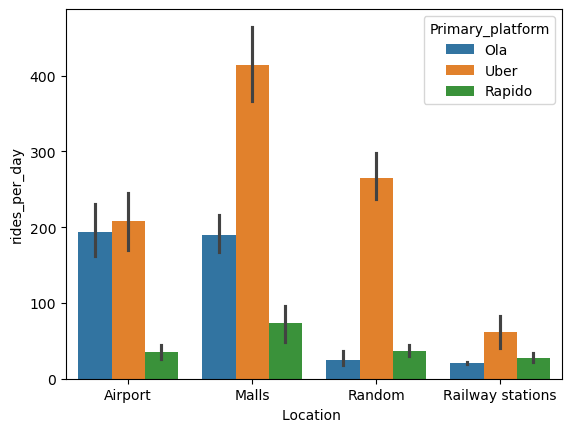

In [43]:
sns.barplot(x="Location ",y="rides_per_day",data=df,estimator=sum,hue="Primary_platform")

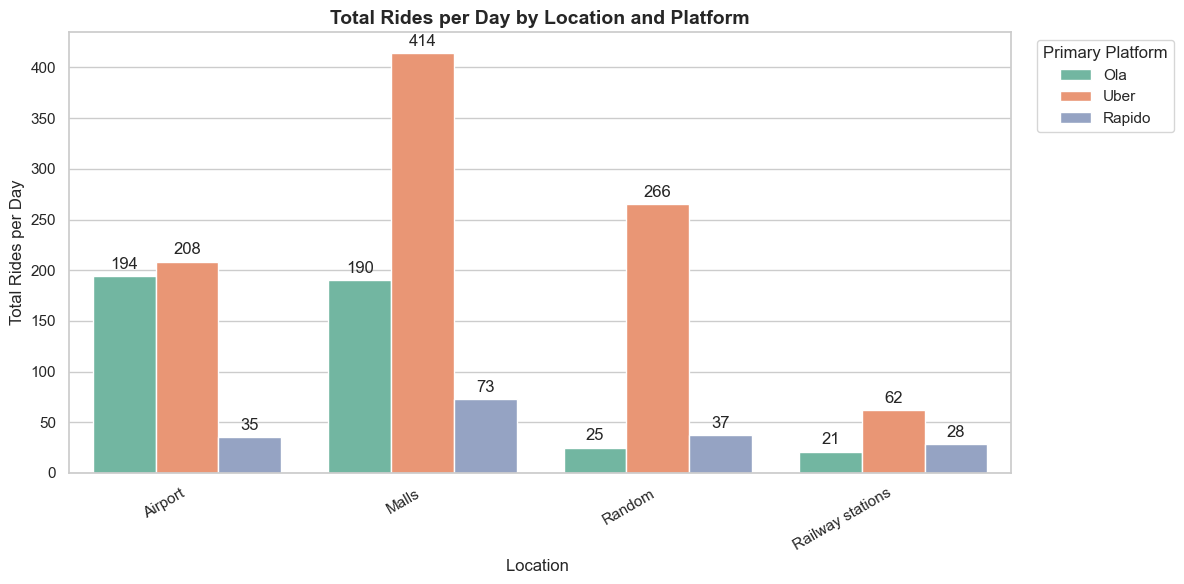

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="Location ",
    y="rides_per_day",
    hue="Primary_platform",
    data=df,
    estimator=sum,
    errorbar=None,          # removes CI bars (important for sums)
    palette="Set2"
)

# Titles & labels
ax.set_title("Total Rides per Day by Location and Platform", fontsize=14, weight="bold")
ax.set_xlabel("Location ", fontsize=12)
ax.set_ylabel("Total Rides per Day", fontsize=12)

# Rotate x labels if many locations
plt.xticks(rotation=30, ha="right")

# Legend formatting
plt.legend(title="Primary Platform", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.savefig("Total_Rides_per_Day_by_Location_and_Platform.png", dpi = 300, bbox_inches = "tight")
plt.show()

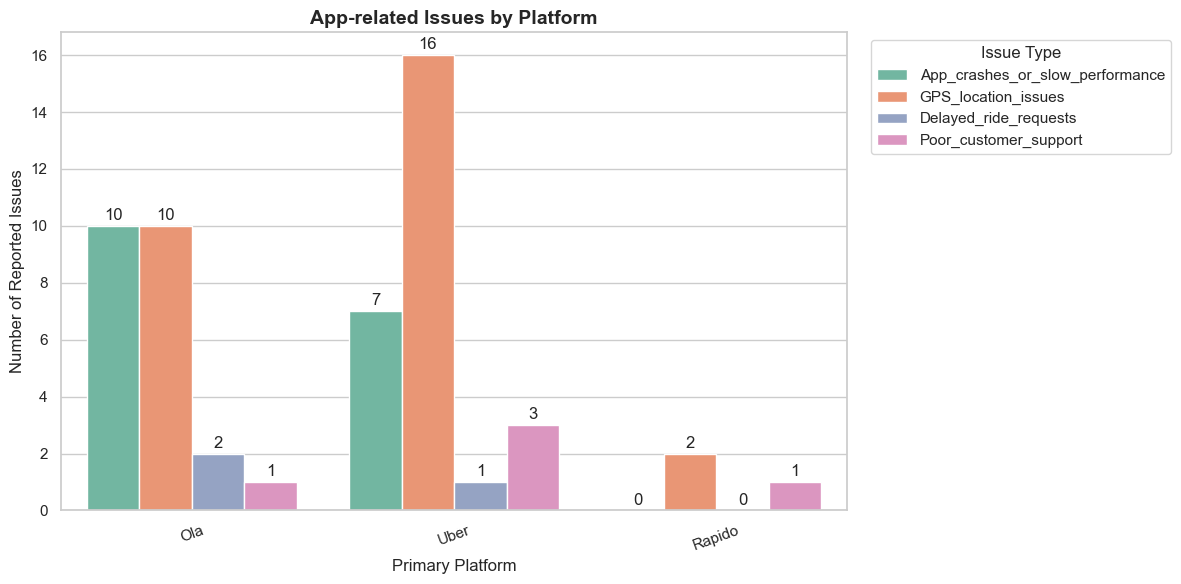

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reset index & melt
plot_df = app_issue_summary.reset_index().melt(
    id_vars="Primary_platform",
    var_name="Issue_Type",
    value_name="Count"
)

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="Primary_platform",
    y="Count",
    hue="Issue_Type",
    palette="Set2"
)

ax.set_title("App-related Issues by Platform", fontsize=14, weight="bold")
ax.set_xlabel("Primary Platform")
ax.set_ylabel("Number of Reported Issues")

plt.xticks(rotation=20)
plt.legend(title="Issue Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.tight_layout()
plt.show()


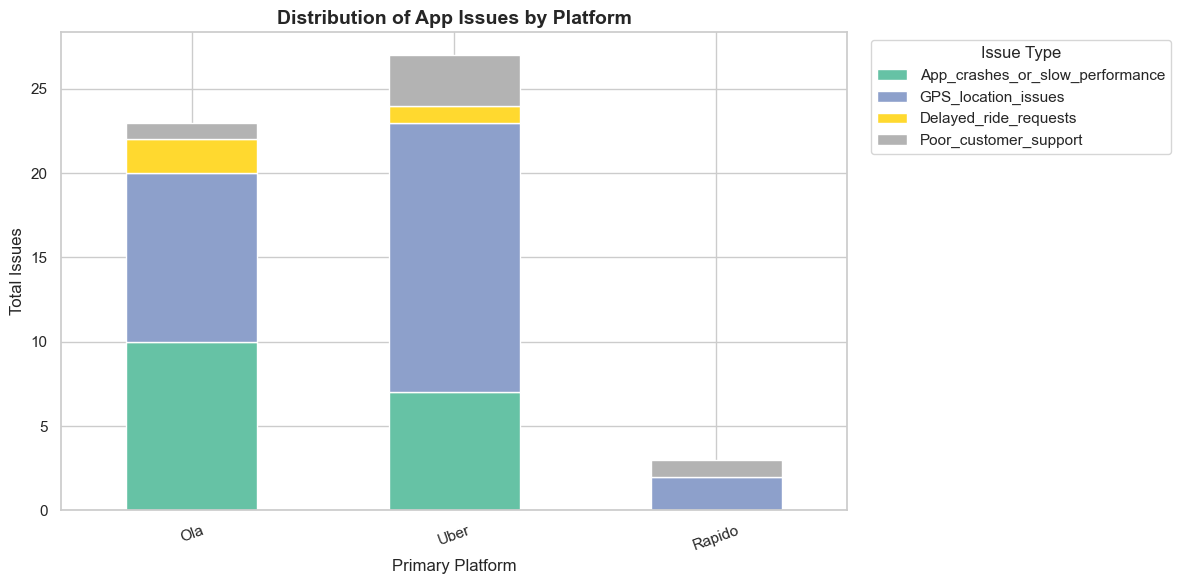

In [46]:
app_issue_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Distribution of App Issues by Platform", fontsize=14, weight="bold")
plt.xlabel("Primary Platform")
plt.ylabel("Total Issues")
plt.xticks(rotation=20)
plt.legend(title="Issue Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


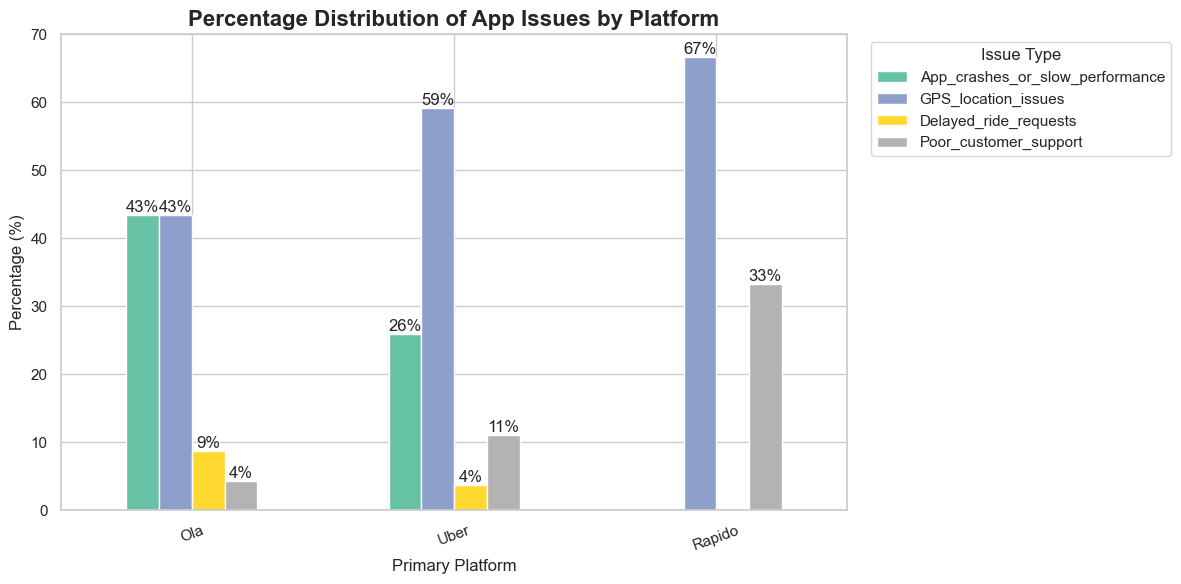

In [128]:
percent_df = app_issue_summary.div(app_issue_summary.sum(axis=1), axis=0) * 100

percent_df.plot(
    kind="bar",
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Percentage Distribution of App Issues by Platform", fontsize=16, weight="bold")
plt.xlabel("Primary Platform",fontsize=12)
plt.ylabel("Percentage (%)",fontsize=12)
plt.xticks(rotation=20)
plt.legend(title="Issue Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# 🔥 add percent labels
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.0f}%" if v > 0 else "" for v in container.datavalues],
        label_type="edge",
        fontsize=12
    )

plt.tight_layout()
plt.savefig("Percentage Distribution of App Issues by Platform.png", dpi = 300, bbox_inches = "tight")
plt.show()


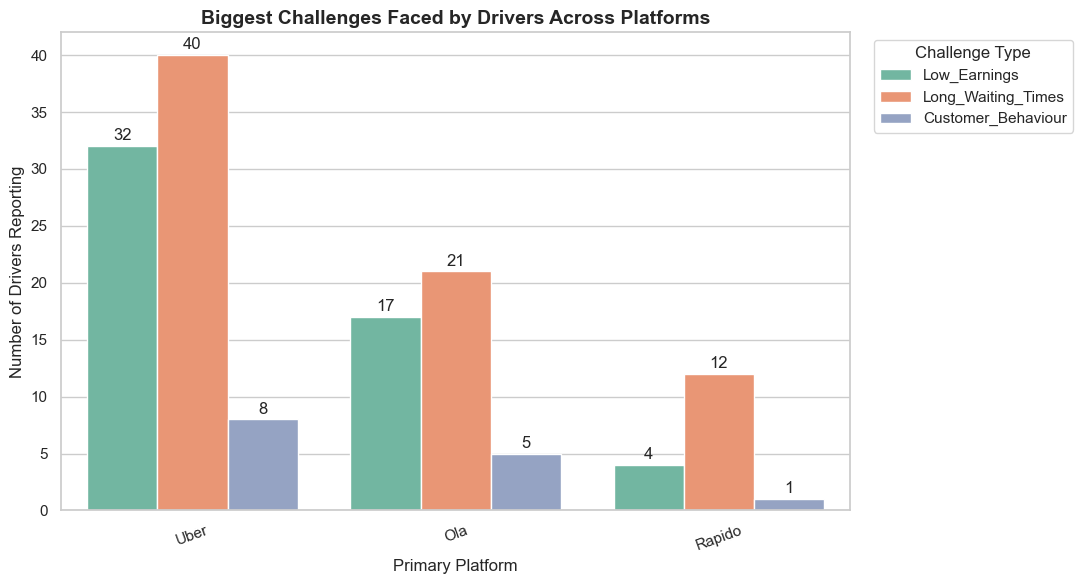

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# reshape wide → long
plot_df = biggest_challenge_summary.reset_index().melt(
    id_vars="Primary_platform",
    var_name="Challenge",
    value_name="Count"
)

plt.figure(figsize=(11,6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="Primary_platform",
    y="Count",
    hue="Challenge",
    palette="Set2"
)

ax.set_title("Biggest Challenges Faced by Drivers Across Platforms", fontsize=14, weight="bold")
ax.set_xlabel("Primary Platform")
ax.set_ylabel("Number of Drivers Reporting")

plt.xticks(rotation=20)
plt.legend(title="Challenge Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.tight_layout()
plt.show()


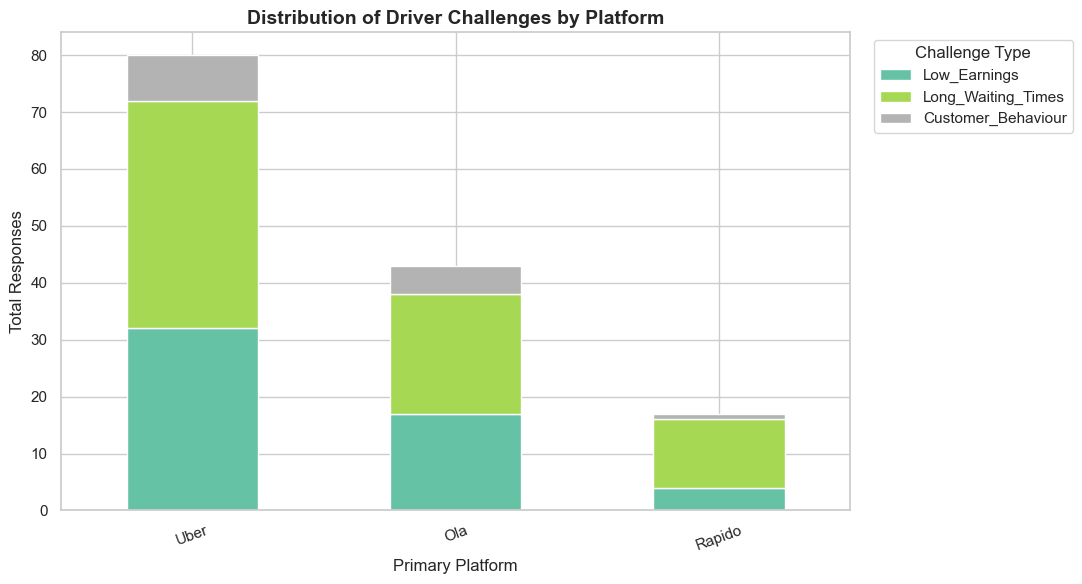

In [49]:
biggest_challenge_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    colormap="Set2"
)

plt.title("Distribution of Driver Challenges by Platform", fontsize=14, weight="bold")
plt.xlabel("Primary Platform")
plt.ylabel("Total Responses")
plt.xticks(rotation=20)
plt.legend(title="Challenge Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


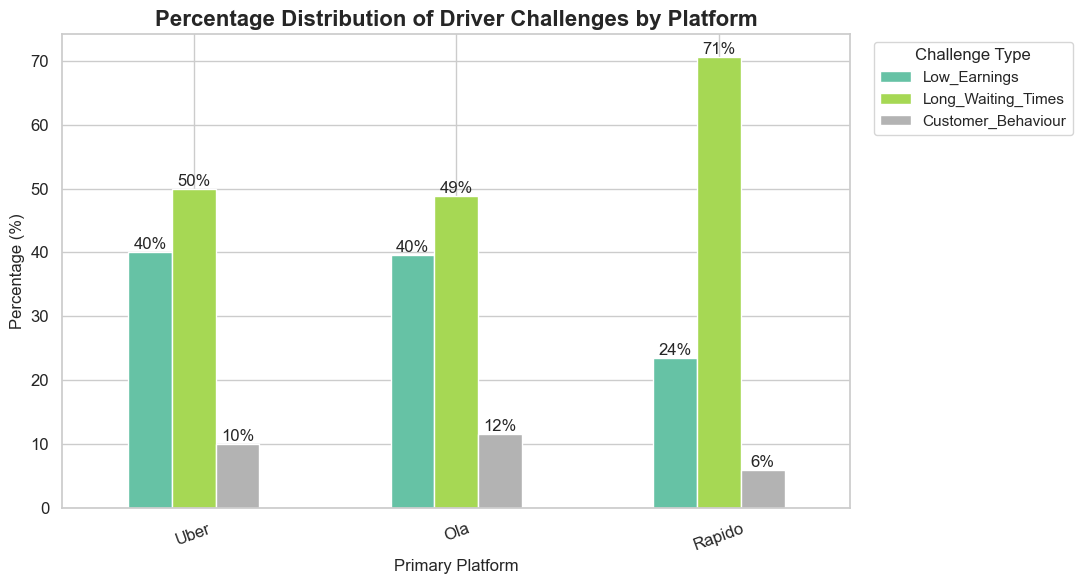

In [125]:
import matplotlib.pyplot as plt

percent_df = biggest_challenge_summary.div(
    biggest_challenge_summary.sum(axis=1), axis=0
) * 100

percent_df.plot(
    kind="bar",
    figsize=(11,6),
    fontsize=12,
    colormap="Set2"
)

plt.title("Percentage Distribution of Driver Challenges by Platform", fontsize=16, weight="bold")
plt.xlabel("Primary Platform",fontsize=12)
plt.ylabel("Percentage (%)",fontsize=12)
plt.xticks(rotation=20)
plt.legend(title="Challenge Type", bbox_to_anchor=(1.02, 1), loc="upper left")

# 🔥 add percent labels
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.0f}%" if v > 0 else "" for v in container.datavalues],
        label_type="edge",
        fontsize=12
    )

plt.tight_layout()
plt.savefig(
    "Percentage Distribution of Driver Challenges by Platform.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [51]:
checkbox_col1 = 'more_rides_days'

options = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

for opt in options:
    col_name = 'issue_' + opt.lower().replace(' ', '_').replace('/', '_')
    df[col_name] = df[checkbox_col1].str.contains(opt, na=False).astype(int)

In [52]:
df.columns

Index(['vehicle_type', 'Location ', 'Primary_platform', 'other_platform',
       'other_platform_2', 'age', 'age_group', 'employement_type',
       'main_reason', 'experience_years', 'avg_daily_earnings',
       'platform_highest_rides', 'back_to_back_ola', 'back_to_back_uber',
       'back_to_back_rapido', 'rides_per_day', 'work_hours',
       'ride_demand_afternoon', 'ride_demand_night', 'ride_demand_midnight',
       'more_rides_days', 'distance_pref', 'biggest_challenges', 'app_issues',
       'desired_improvement', 'satisfaction_uber', 'satisfaction_ola',
       'satisfaction_rapido', 'challenge_low_earnings',
       'challenge_long_waiting_times', 'challenge_customer_behavior',
       'challenge_penalties', 'issue_app_crashes_or_slow_performance',
       'issue_gps_location_issues', 'issue_delayed_ride_requests',
       'issue_poor_customer_support', 'issue_monday', 'issue_tuesday',
       'issue_wednesday', 'issue_thursday', 'issue_friday', 'issue_saturday',
       'issue_sunday

In [53]:
week_day_summary = df.groupby("Primary_platform").agg(
    Low_Earnings=("challenge_low_earnings","sum"),
    Long_Waiting_Times=("challenge_long_waiting_times","sum"),
    Customer_Behaviour=("challenge_customer_behavior","sum"),
).sort_values("Low_Earnings", ascending=False)

week_day_summary

,Low_Earnings,Long_Waiting_Times,Customer_Behaviour
Primary_platform,,,
Uber,32,40,8
Ola,17,21,5
Rapido,4,12,1


In [54]:
df['day_list'] = df['more_rides_days'].str.split(', ')
df['day_count'] = df['day_list'].apply(len)
df_exploded = df.explode('day_list')
df_exploded['distributed_rides'] = (
    df_exploded['rides_per_day'] / df_exploded['day_count']
)
daywise_rides = (
    df_exploded
    .groupby(['day_list', 'Primary_platform'])['distributed_rides']
    .sum()
    .reset_index()
)
pivot_daywise = daywise_rides.pivot(
    index='day_list',
    columns='Primary_platform',
    values='distributed_rides'
)

pivot_daywise = pivot_daywise.reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).fillna(0)

round(pivot_daywise,0)

Primary_platform,Ola,Rapido,Uber
day_list,,,
Monday,59.0,25.0,170.0
Tuesday,47.0,2.0,66.0
Wednesday,23.0,2.0,67.0
Thursday,38.0,2.0,60.0
Friday,35.0,6.0,79.0
Saturday,110.0,62.0,233.0
Sunday,118.0,72.0,274.0


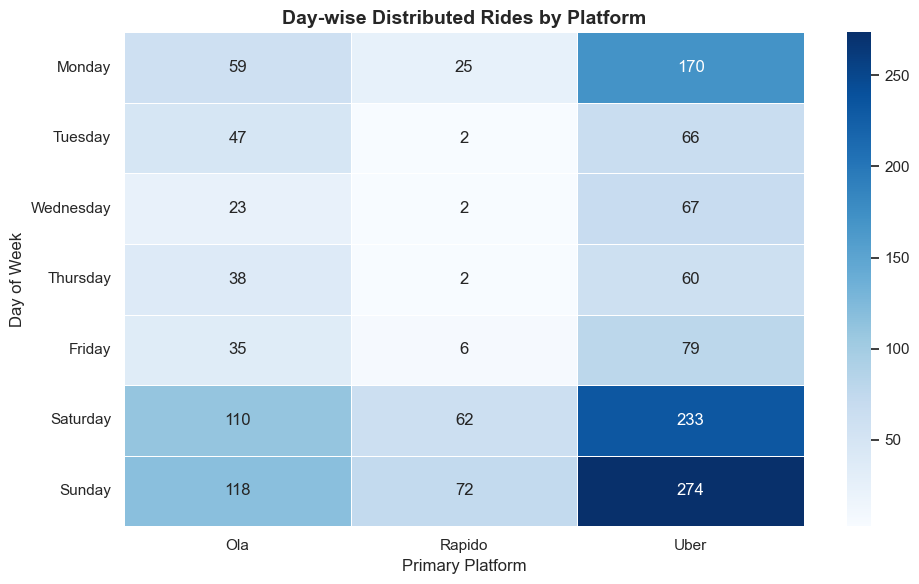

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.set_theme(style="white")

ax = sns.heatmap(
    pivot_daywise,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5
)

ax.set_title("Day-wise Distributed Rides by Platform", fontsize=14, weight="bold")
ax.set_xlabel("Primary Platform")
ax.set_ylabel("Day of Week")

plt.tight_layout()
plt.savefig("Day-wise Distributed Rides by Platform.png", dpi = 300, bbox_inches = "tight")
plt.show()


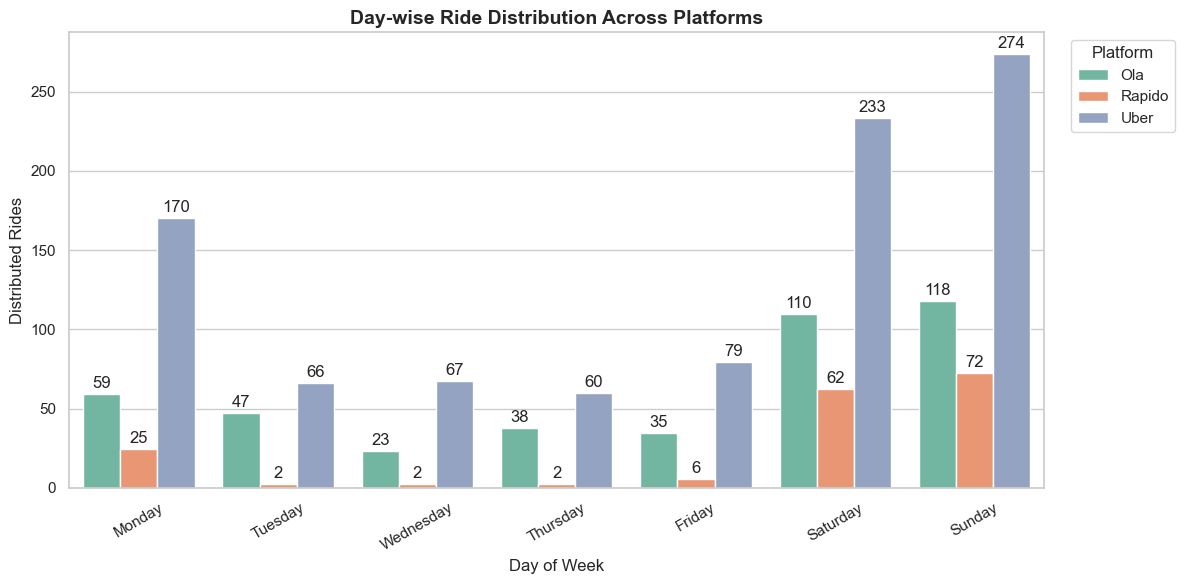

In [56]:
plot_df = pivot_daywise.reset_index().melt(
    id_vars="day_list",
    var_name="Primary_platform",
    value_name="Distributed Rides"
)

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="day_list",
    y="Distributed Rides",
    hue="Primary_platform",
    palette="Set2"
)

ax.set_title("Day-wise Ride Distribution Across Platforms", fontsize=14, weight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Distributed Rides")

plt.xticks(rotation=30)
plt.legend(title="Platform", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.tight_layout()
plt.show()


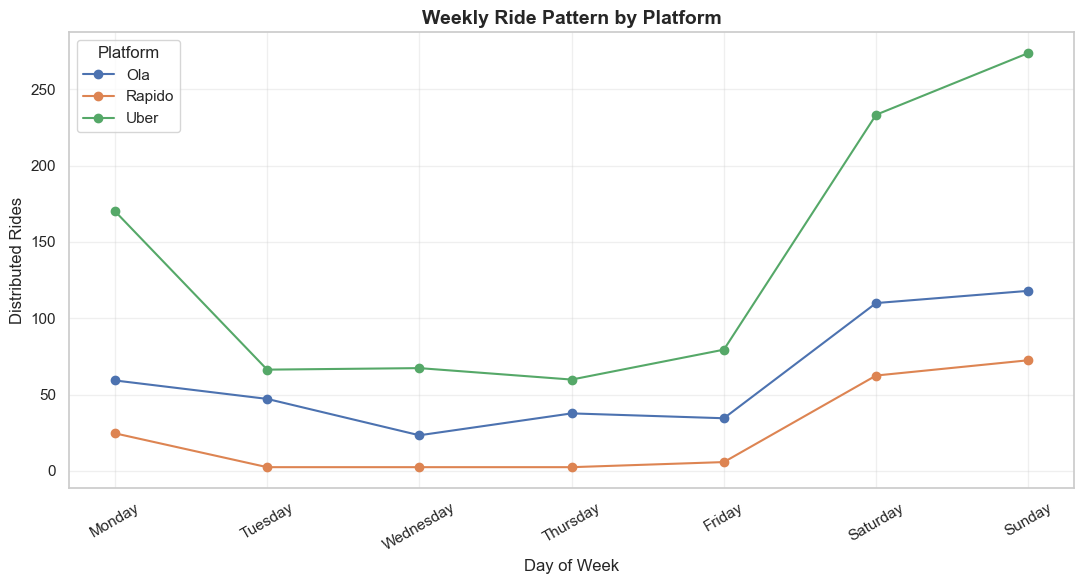

In [57]:
plt.figure(figsize=(11,6))

for col in pivot_daywise.columns:
    plt.plot(
        pivot_daywise.index,
        pivot_daywise[col],
        marker='o',
        label=col
    )

plt.title("Weekly Ride Pattern by Platform", fontsize=14, weight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Distributed Rides")
plt.xticks(rotation=30)
plt.legend(title="Platform")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Weekly Ride Pattern by Platform.png", dpi = 300, bbox_inches = "tight")
plt.show()


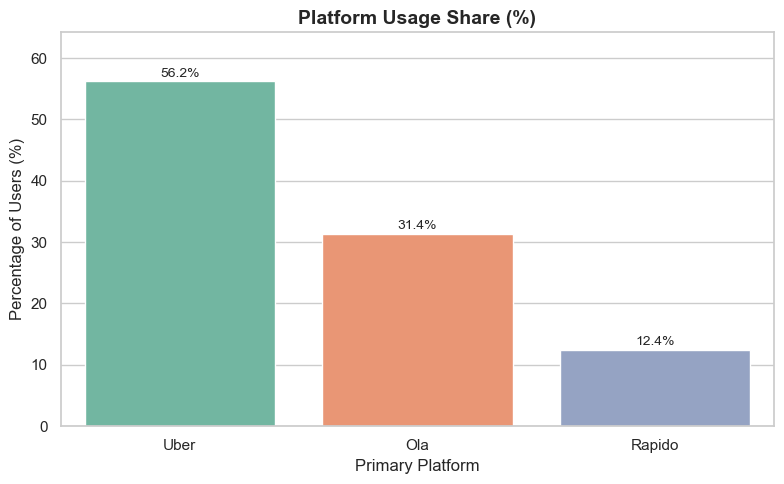

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

platform_percent = df['Primary_platform'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=platform_percent.index,
    y=platform_percent.values,
    palette="Set2"
)

ax.set_title("Platform Usage Share (%)", fontsize=14, weight="bold")
ax.set_xlabel("Primary Platform")
ax.set_ylabel("Percentage of Users (%)")

# value labels
for i, v in enumerate(platform_percent.values):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)

plt.ylim(0, platform_percent.max() + 8)
plt.tight_layout()
plt.show()


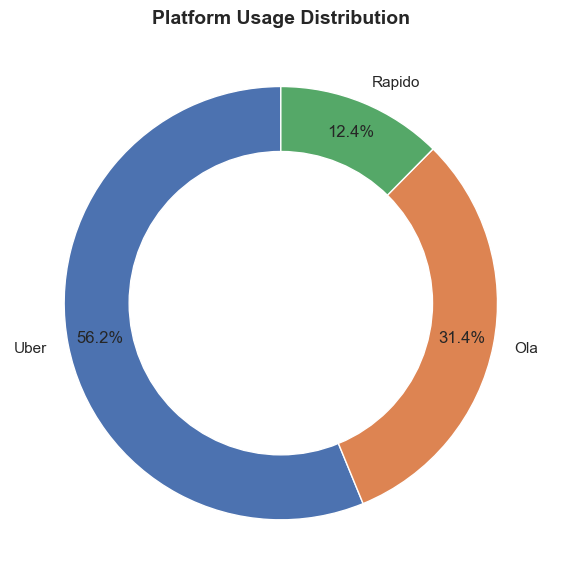

In [59]:
plt.figure(figsize=(6,6))

plt.pie(
    platform_percent.values,
    labels=platform_percent.index,
    autopct="%.1f%%",
    startangle=90,
    pctdistance=0.85
)

# donut hole
centre_circle = plt.Circle((0,0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Platform Usage Distribution", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("Platform Usage Distribution.png", dpi = 300, bbox_inches = "tight")
plt.show()


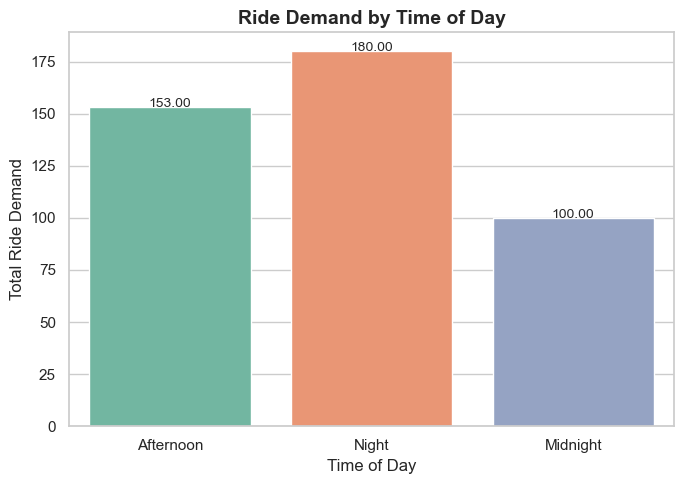

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

time_cols = ['ride_demand_afternoon', 'ride_demand_night', 'ride_demand_midnight']
time_avg = df[time_cols].sum()

plt.figure(figsize=(7,5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=time_avg.index,
    y=time_avg.values,
    palette="Set2"
)

ax.set_title("Ride Demand by Time of Day", fontsize=14, weight="bold")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Total Ride Demand")

# clean x labels
ax.set_xticklabels(['Afternoon', 'Night', 'Midnight'])

# value labels
for i, v in enumerate(time_avg.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("Ride Demand by Time of Day.png", dpi = 300, bbox_inches = "tight")
plt.show()


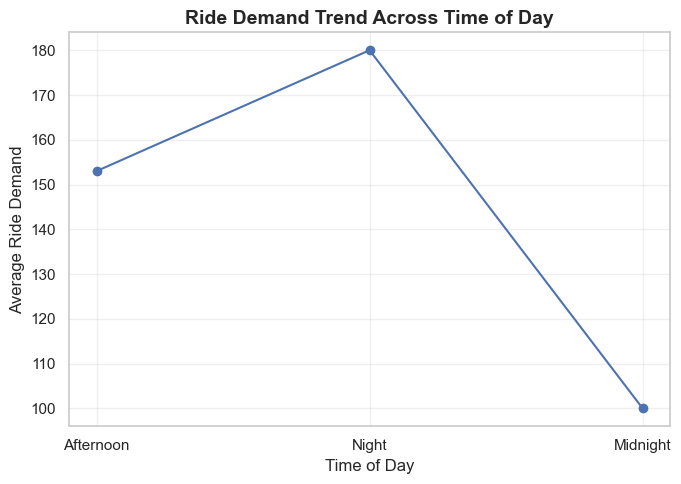

In [61]:
plt.figure(figsize=(7,5))

plt.plot(
    ['Afternoon', 'Night', 'Midnight'],
    time_avg.values,
    marker='o'
)

plt.title("Ride Demand Trend Across Time of Day", fontsize=14, weight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Average Ride Demand")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


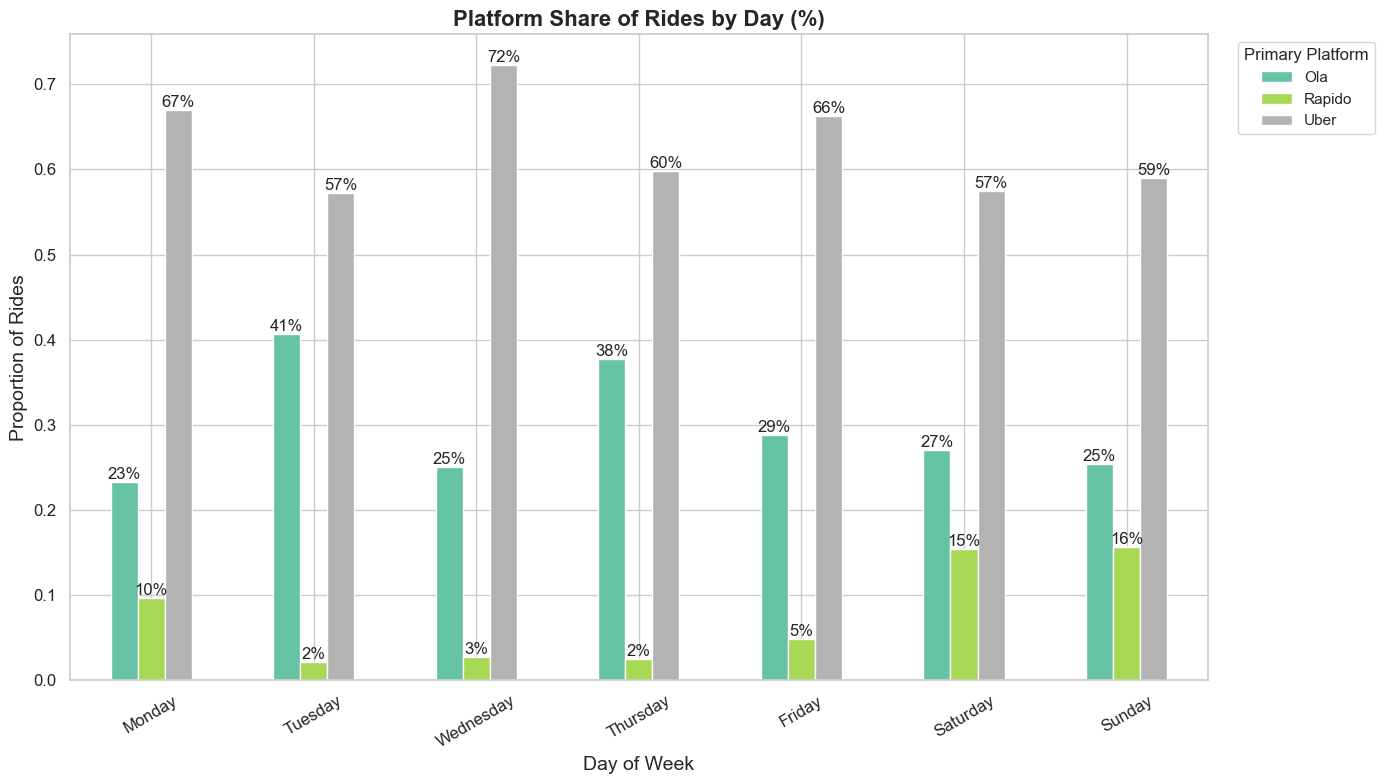

In [120]:
import matplotlib.pyplot as plt
pivot_percent = pivot_daywise.div(pivot_daywise.sum(axis=1), axis=0)
plt.figure(figsize=(14,8))

pivot_percent.plot(
    kind="bar",
    colormap="Set2",
    fontsize=12,
    ax=plt.gca()
)

plt.title("Platform Share of Rides by Day (%)", fontsize=16, weight="bold")
plt.xlabel("Day of Week",fontsize=14)
plt.ylabel("Proportion of Rides",fontsize=14)

plt.xticks(rotation=30)
plt.legend(title="Primary Platform", bbox_to_anchor=(1.02, 1), loc="upper left")
ax = plt.gca()

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.0f}%" if v > 0 else "" for v in container.datavalues],
        label_type="edge",
        fontsize=12
    )


plt.tight_layout()
plt.savefig("Platform Share of Rides by Day (%).png", dpi = 300, bbox_inches = "tight")
plt.show()


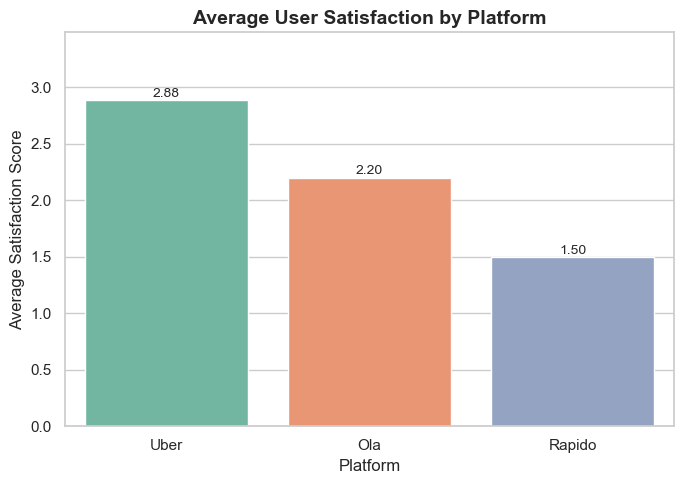

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

satisfaction_cols = [
    'satisfaction_uber',
    'satisfaction_ola',
    'satisfaction_rapido'
]

# calculate mean
satisfaction_mean = df[satisfaction_cols].mean()

plt.figure(figsize=(7,5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=satisfaction_mean.index,
    y=satisfaction_mean.values,
    palette="Set2"
)

ax.set_title("Average User Satisfaction by Platform", fontsize=14, weight="bold")
ax.set_xlabel("Platform")
ax.set_ylabel("Average Satisfaction Score")

# clean x labels
ax.set_xticklabels(['Uber', 'Ola', 'Rapido'])

# value labels
for i, v in enumerate(satisfaction_mean.values):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=10)

plt.ylim(0, satisfaction_mean.max() + 0.6)
plt.tight_layout()
plt.savefig("Average User Satisfaction by Platform.png", dpi = 300, bbox_inches = "tight")
plt.show()


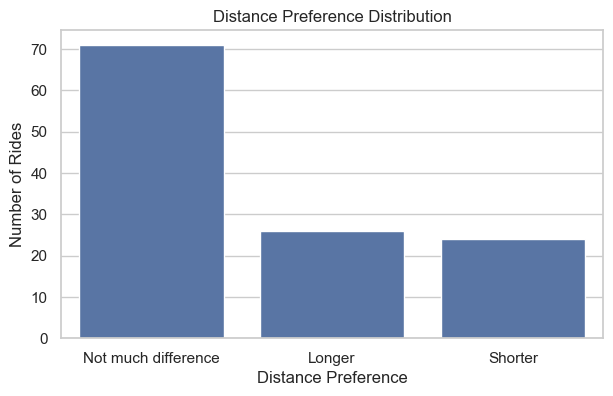

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count values
distance_counts = df['distance_pref'].value_counts().reset_index()
distance_counts.columns = ['distance_pref', 'count']

# Plot
plt.figure(figsize=(7,4))
sns.barplot(
    data=distance_counts,
    x='distance_pref',
    y='count'
)

plt.title('Distance Preference Distribution')
plt.xlabel('Distance Preference')
plt.ylabel('Number of Rides')
plt.show()


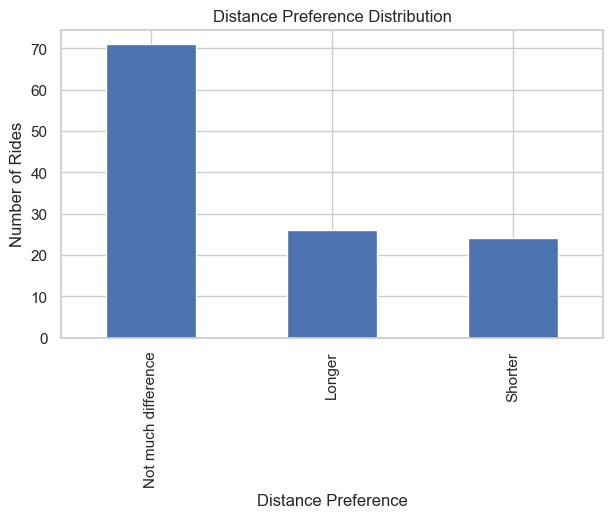

In [65]:
plt.figure(figsize=(7,4))
df['distance_pref'].value_counts().plot(kind='bar')

plt.title('Distance Preference Distribution')
plt.xlabel('Distance Preference')
plt.ylabel('Number of Rides')
plt.show()


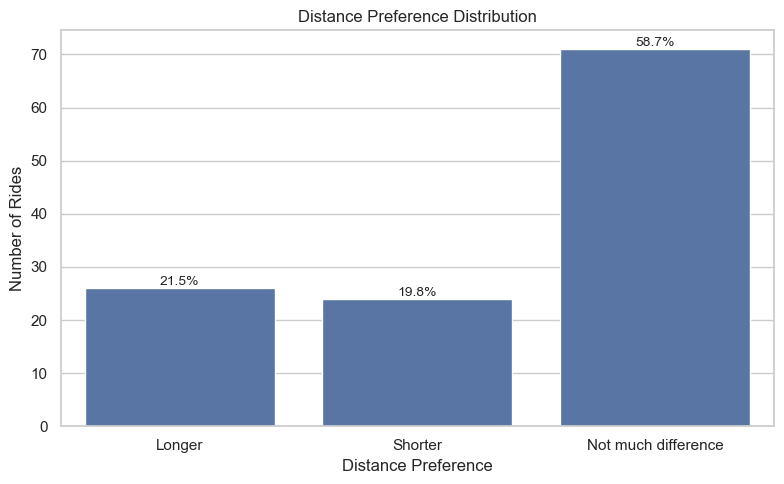

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

total = distance_counts['count'].sum()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=distance_counts,
    x='distance_pref',
    y='count',
    order=order
)

plt.title('Distance Preference Distribution')
plt.xlabel('Distance Preference')
plt.ylabel('Number of Rides')

# 🔥 add percentage labels on top
for p in ax.patches:
    percent = (p.get_height() / total) * 100
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Distance Preference Distribution.png", dpi=300, bbox_inches="tight")
plt.show()



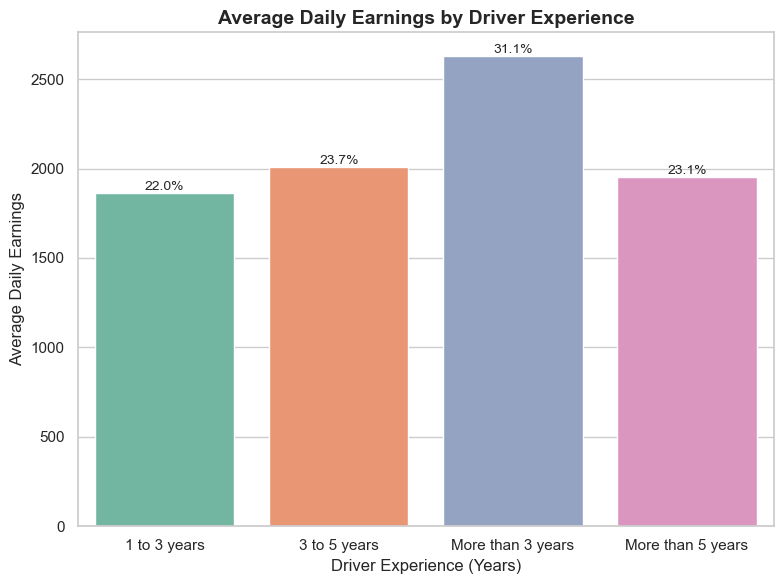

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

# aggregate
avg_earnings = (
    df.groupby("experience_years")["avg_daily_earnings"]
      .mean()
      .reset_index()
)

total = avg_earnings["avg_daily_earnings"].sum()

plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=avg_earnings,
    x="experience_years",
    y="avg_daily_earnings",
    palette="Set2",
    errorbar=None
)

ax.set_title("Average Daily Earnings by Driver Experience", fontsize=14, weight="bold")
ax.set_xlabel("Driver Experience (Years)")
ax.set_ylabel("Average Daily Earnings")

# 🔥 percentage labels
for p in ax.patches:
    percent = (p.get_height() / total) * 100
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Average Daily Earnings by Driver Experience.png", dpi = 300, bbox_inches = "tight")
plt.show()


In [68]:
df[['experience_years', 'avg_daily_earnings']].dtypes

experience_years      object
avg_daily_earnings     int64
dtype: object

In [69]:
import pandas as pd

avg_earnings = (
    df.groupby("experience_years")["avg_daily_earnings"]
      .mean()
      .reset_index()
)


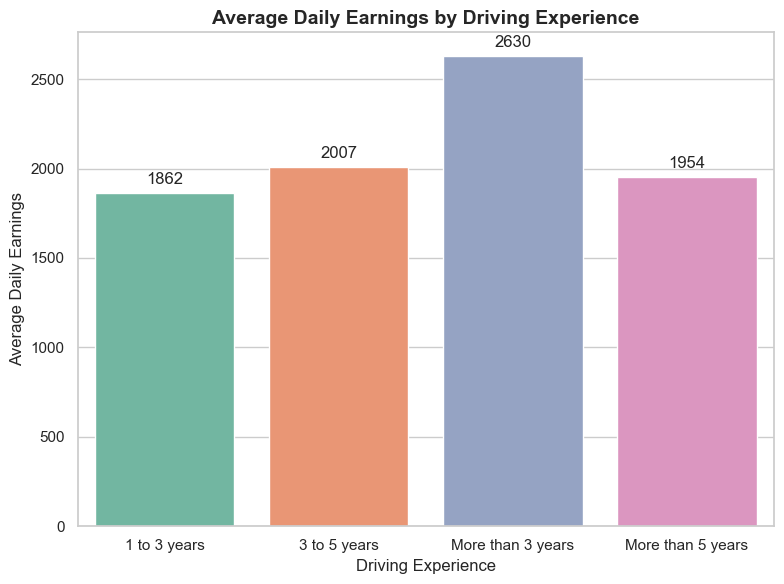

In [70]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=avg_earnings,
    x="experience_years",
    y="avg_daily_earnings",
    palette="Set2"
)

ax.set_title("Average Daily Earnings by Driving Experience", fontsize=14, weight="bold")
ax.set_xlabel("Driving Experience")
ax.set_ylabel("Average Daily Earnings")

for i, v in enumerate(avg_earnings['avg_daily_earnings']):
    ax.text(i, v + 50, f"{v:.0f}", ha="center")

plt.tight_layout()
plt.savefig("Average Daily Earnings by Driving Experience.png", dpi = 300, bbox_inches = "tight")
plt.show()


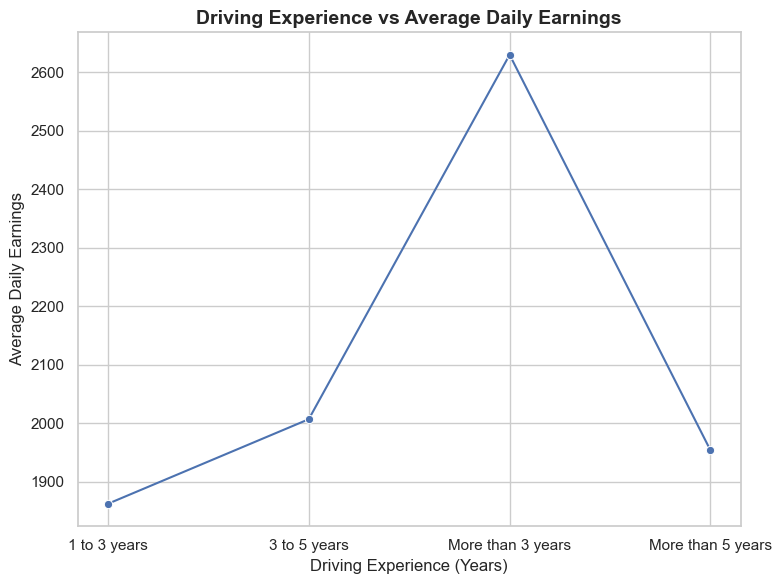

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=avg_earnings,
    x="experience_years",
    y="avg_daily_earnings",
    marker="o"
)

ax.set_title("Driving Experience vs Average Daily Earnings", fontsize=14, weight="bold")
ax.set_xlabel("Driving Experience (Years)")
ax.set_ylabel("Average Daily Earnings")

plt.tight_layout()
plt.show()


In [72]:
import pandas as pd

avg_earnings_vel = (
    df.groupby("vehicle_type")["avg_daily_earnings"]
      .mean()
      .reset_index()
)

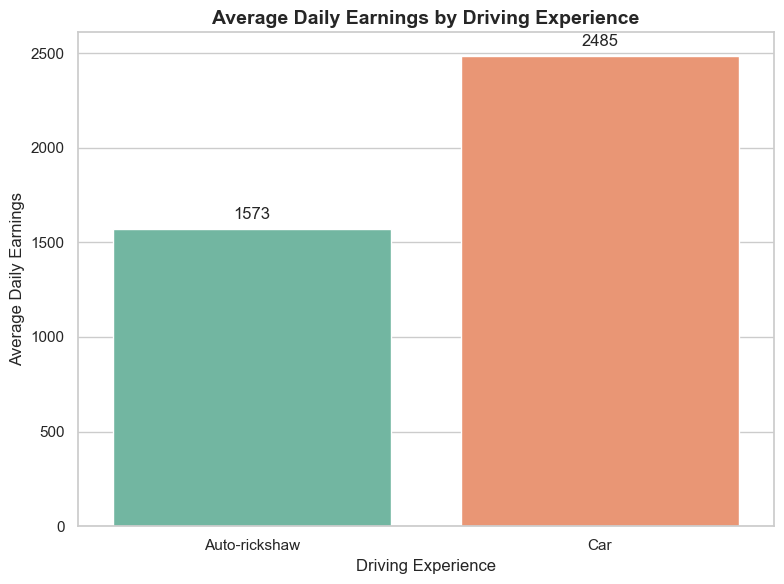

In [73]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=avg_earnings_vel,
    x="vehicle_type",
    y="avg_daily_earnings",
    palette="Set2"
)

ax.set_title("Average Daily Earnings by Driving Experience", fontsize=14, weight="bold")
ax.set_xlabel("Driving Experience")
ax.set_ylabel("Average Daily Earnings")

for i, v in enumerate(avg_earnings_vel['avg_daily_earnings']):
    ax.text(i, v + 50, f"{v:.0f}", ha="center")

plt.tight_layout()
plt.savefig("Average Daily Earnings by Driving Experience.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [74]:
# Define age groups
bins = [18, 30, 45, 60, 100]  # adjust based on your dataset
labels = ['18-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Count per group
age_counts = df['age_group'].value_counts().sort_index()

# Convert counts to percentage
age_percent = (age_counts / age_counts.sum()) * 100
print(age_percent)

age_group
18-30    33.884298
31-45    56.198347
46-60     9.090909
60+       0.826446
Name: count, dtype: float64


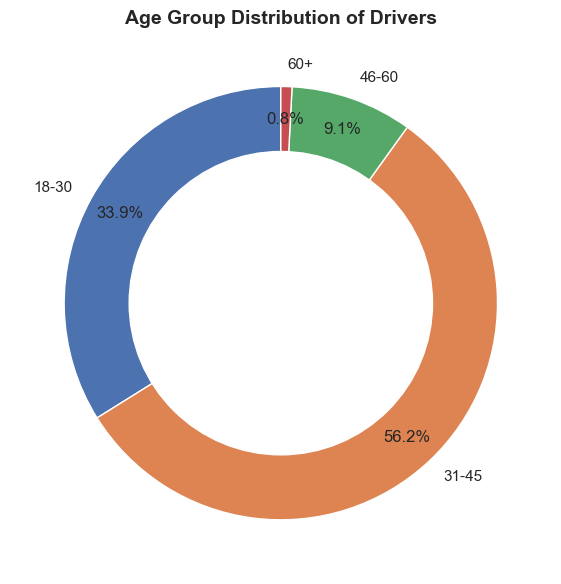

In [75]:
plt.figure(figsize=(6,6))

plt.pie(
    age_percent.values,
    labels=age_percent.index,
    autopct="%.1f%%",
    startangle=90,
    pctdistance=0.85
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Age Group Distribution of Drivers", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("Age Group Distribution of Drivers.png", dpi = 300, bbox_inches = "tight")
plt.show()


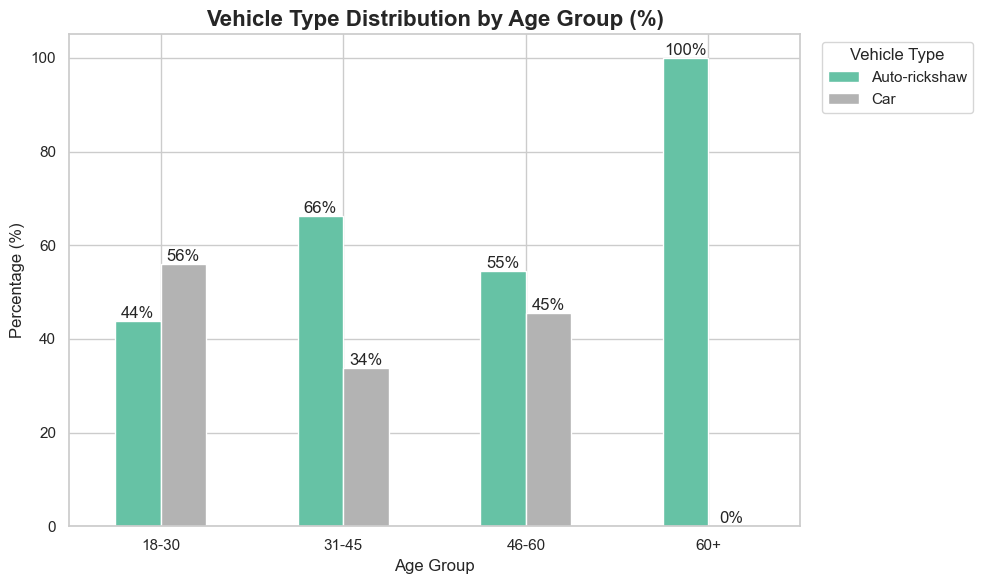

In [130]:
import matplotlib.pyplot as plt
age_vehicle = pd.crosstab(df['age_group'], df['vehicle_type'], normalize='index') * 100
plt.figure(figsize=(10,6))

age_vehicle.plot(
    kind="bar",
    colormap="Set2",
    ax=plt.gca()
)
ax = plt.gca()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        label_type="edge",
        fontsize=12
    )

plt.title("Vehicle Type Distribution by Age Group (%)", fontsize=16, weight="bold")
plt.xlabel("Age Group",fontsize=12)
plt.ylabel("Percentage (%)",fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("Vehicle Type Distribution by Age Group (%).png", dpi = 300, bbox_inches = "tight")
plt.show()


In [77]:
import pandas as pd

age_platform = pd.crosstab(
    df['age_group'],
    df['Primary_platform'],
    normalize='index'
) * 100

print(age_platform)

Primary_platform        Ola     Rapido        Uber
age_group                                         
18-30             46.341463  14.634146   39.024390
31-45             23.529412  10.294118   66.176471
46-60             27.272727  18.181818   54.545455
60+                0.000000   0.000000  100.000000


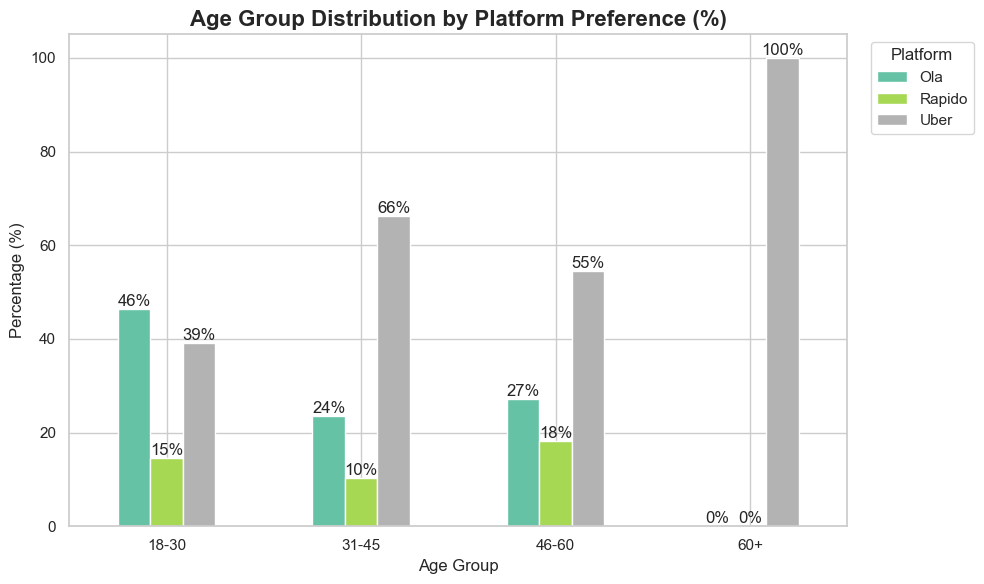

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

age_platform.plot(
    kind="bar",
    colormap="Set2",
    ax=plt.gca()
)
ax = plt.gca()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        label_type="edge",
        fontsize=12
    )

plt.title("Age Group Distribution by Platform Preference (%)", fontsize=16, weight="bold")
plt.xlabel("Age Group",fontsize=12)
plt.ylabel("Percentage (%)",fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Platform", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("Age Group Distribution by Platform Preference(%).png", dpi = 300, bbox_inches = "tight")
plt.show()

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   vehicle_type                           121 non-null    object  
 1   Location                               121 non-null    object  
 2   Primary_platform                       121 non-null    object  
 3   other_platform                         121 non-null    object  
 4   other_platform_2                       121 non-null    object  
 5   age                                    121 non-null    int64   
 6   age_group                              121 non-null    category
 7   employement_type                       121 non-null    object  
 8   main_reason                            121 non-null    object  
 9   experience_years                       121 non-null    object  
 10  avg_daily_earnings                     121 non-null    int64  

In [80]:
work_map = {
    'Less than 6 hours': 5,
    '6–8 hours': 7,
    '8–10 hours': 9,
    'More than 10 hours': 11
}

df['work_hours'] = df['work_hours'].map(work_map)

In [81]:
df['work_hours'].dtype  # should be int or float

dtype('float64')

In [82]:
exp_map = {
    '1 to 3 years': 2,
    'More than 3 years': 4
}

df['exp_yrs_mid'] = df['experience_years'].map(exp_map)

In [83]:
df['satisfaction_primary'] = df.apply(
    lambda r: r['satisfaction_' + r['Primary_platform'].lower()],
    axis=1
).astype(int)

In [84]:
issue_cols = [
    'issue_app_crashes_or_slow_performance',
    'issue_gps_location_issues',
    'issue_delayed_ride_requests',
    'issue_poor_customer_support'
]

df['issues_count'] = df[issue_cols].sum(axis=1)

In [85]:
challenge_cols = [
    'challenge_low_earnings',
    'challenge_long_waiting_times',
    'challenge_customer_behavior',
    'challenge_penalties'
]

df['challenge_count'] = df[challenge_cols].sum(axis=1)

In [86]:
model_cols = [
    'avg_daily_earnings',
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'issues_count',
    'challenge_count',
    'day_count',
    'satisfaction_primary'
]

df_model = df[model_cols].dropna()

In [87]:
df_model.dtypes

avg_daily_earnings        int64
rides_per_day           float64
work_hours              float64
exp_yrs_mid             float64
issues_count              int64
challenge_count           int64
day_count                 int64
satisfaction_primary      int32
dtype: object

In [88]:
exog = df_model.drop('satisfaction_primary', axis=1)
endog = df_model['satisfaction_primary']

model = OrderedModel(endog, exog, distr='logit')
res = model.fit(method='bfgs')
print(res.summary())

         Current function value: 0.984938
         Iterations: 60
         Function evaluations: 111
         Gradient evaluations: 100
                              OrderedModel Results                              
Dep. Variable:     satisfaction_primary   Log-Likelihood:                -39.398
Model:                     OrderedModel   AIC:                             98.80
Method:              Maximum Likelihood   BIC:                             115.7
Date:                  Fri, 06 Feb 2026                                         
Time:                          14:58:37                                         
No. Observations:                    40                                         
Df Residuals:                        30                                         
Df Model:                             7                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [89]:
features = [
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'challenge_count',
    'issues_count',
    'day_count'
]

In [90]:
features = [
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'challenge_count',
    'issues_count',
    'day_count'
]

corr_matrix = df[features].corr(method='pearson')
corr_matrix

,rides_per_day,work_hours,exp_yrs_mid,challenge_count,issues_count,day_count
rides_per_day,1.000000,0.290076,-0.346954,-0.022871,-0.022419,0.157477
work_hours,0.290076,1.000000,0.158777,0.066040,-0.009984,-0.088284
exp_yrs_mid,-0.346954,0.158777,1.000000,-0.134272,-0.137063,0.301149
challenge_count,-0.022871,0.066040,-0.134272,1.000000,0.048007,-0.157461
issues_count,-0.022419,-0.009984,-0.137063,0.048007,1.000000,-0.201251
day_count,0.157477,-0.088284,0.301149,-0.157461,-0.201251,1.000000


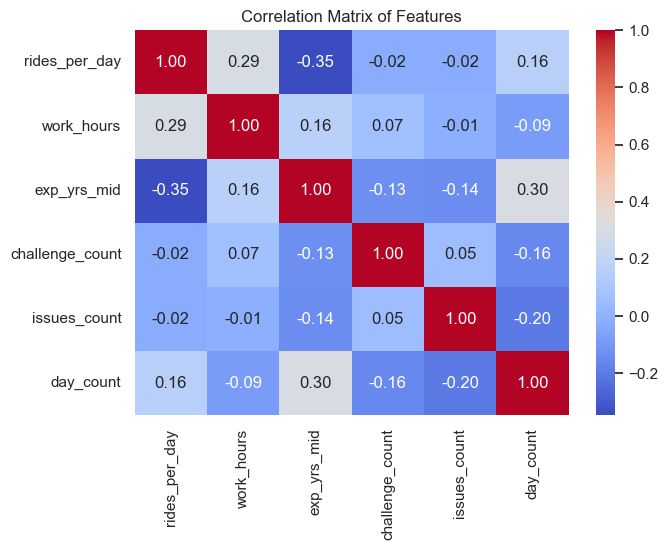

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[features].dropna()
vif = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif

,Feature,VIF
0,rides_per_day,6.954757
1,work_hours,27.184709
2,exp_yrs_mid,13.105093
3,challenge_count,9.289681
4,issues_count,1.597289
5,day_count,4.535440


In [93]:
df['satisfied'] = (df['satisfaction_primary'] >= 3).astype(int)

In [94]:
df_ml = pd.get_dummies(
    df[['vehicle_type','employement_type','Primary_platform'] + features],
    drop_first=True
)

In [95]:
from sklearn.model_selection import train_test_split

X = df_ml
y = df['avg_daily_earnings']   # for regression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [96]:
features = [
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'challenge_count',
    'issues_count',
    'day_count'
]

X = df[features]
y = df['satisfied']

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [100]:
features = [
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'challenge_count',
    'issues_count',
    'day_count'
]

df[features].isna().sum()


rides_per_day       0
work_hours         46
exp_yrs_mid        64
challenge_count     0
issues_count        0
day_count           0
dtype: int64

In [101]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df[features])

y = df['satisfied']

### Logistic Model to Predict Satiction of Driver

In [102]:
# ===============================
# 1. Imports
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===============================
# 2. Define Features & Target
# ===============================

features = [
    'rides_per_day',
    'work_hours',
    'exp_yrs_mid',
    'challenge_count',
    'issues_count',
    'day_count'
]

X = df[features]
y = df['satisfied']   # binary target (0 = not satisfied, 1 = satisfied)

# ===============================
# 3. Median Imputation (KEY STEP)
# ===============================

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Convert back to DataFrame (good practice)
X_imputed = pd.DataFrame(X_imputed, columns=features)

# ===============================
# 4. Train–Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ===============================
# 5. Feature Scaling
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 6. Logistic Regression Model
# ===============================

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# ===============================
# 7. Predictions
# ===============================

y_pred = log_reg.predict(X_train_scaled)

# ===============================
# 8. Model Evaluation
# ===============================

print("Accuracy:", accuracy_score(y_train, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred))
print("\nClassification Report:\n", classification_report(y_train, y_pred))

# ===============================
# 9. Coefficients & Odds Ratios
# ===============================

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
})

coef_df.sort_values(by='Odds_Ratio', ascending=False)


Accuracy: 0.8690476190476191

Confusion Matrix:
 [[ 1 11]
 [ 0 72]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.08      0.15        12
           1       0.87      1.00      0.93        72

    accuracy                           0.87        84
   macro avg       0.93      0.54      0.54        84
weighted avg       0.89      0.87      0.82        84



,Feature,Coefficient,Odds_Ratio
0,rides_per_day,0.758884,2.135892
2,exp_yrs_mid,0.478935,1.614354
4,issues_count,0.067058,1.069358
5,day_count,-0.155661,0.855849
3,challenge_count,-0.483250,0.616775
1,work_hours,-0.707548,0.492851


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 50 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   vehicle_type                           121 non-null    object  
 1   Location                               121 non-null    object  
 2   Primary_platform                       121 non-null    object  
 3   other_platform                         121 non-null    object  
 4   other_platform_2                       121 non-null    object  
 5   age                                    121 non-null    int64   
 6   age_group                              121 non-null    category
 7   employement_type                       121 non-null    object  
 8   main_reason                            121 non-null    object  
 9   experience_years                       121 non-null    object  
 10  avg_daily_earnings                     121 non-null    int64  